In [6]:
%matplotlib inline

In [10]:
import pandas as pd

demand_df = pd.read_csv("demand_df.csv")

In [12]:
demand_df

,MDCODE,INVDT,Demand_Qty,Selling_Rate,Purchase_Rate,Maximum_Retail_Price,MDNAME,PACKG,DETAIL,day,day_name,day_of_week,week,month,month_name,quarter,year,is_weekend,financial_year,financial_month
0,1,2017-12-21,10,15.000000,10.0,30.000000,OTACARE EAR DROPS,5ML,VIAL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2018-01-02,30,42.530000,7.5,63.000000,OTACARE EAR DROPS,5ML,VIAL,2.0,Tuesday,2.0,1.0,1.0,January,1.0,2018.0,False,FY 2017-18,10.0
2,1,2018-01-03,130,40.350000,7.5,55.000000,OTACARE EAR DROPS,5ML,VIAL,3.0,Wednesday,3.0,1.0,1.0,January,1.0,2018.0,False,FY 2017-18,10.0
3,1,2018-01-04,25,37.570000,7.5,55.000000,OTACARE EAR DROPS,5ML,VIAL,4.0,Thursday,4.0,1.0,1.0,January,1.0,2018.0,False,FY 2017-18,10.0
4,1,2018-01-05,380,35.632857,7.9,60.714286,OTACARE EAR DROPS,5ML,VIAL,5.0,Friday,5.0,1.0,1.0,January,1.0,2018.0,False,FY 2017-18,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84096,168,2023-04-24,30,55.000000,25.0,230.000000,PROZON-S INJECTION,1.5gm,1,24.0,Monday,1.0,17.0,4.0,April,2.0,2023.0,False,FY 2023-24,1.0
84097,168,2023-05-29,50,52.000000,25.0,230.000000,PROZON-S INJECTION,1.5gm,1,29.0,Monday,1.0,22.0,5.0,May,2.0,2023.0,False,FY 2023-24,2.0
84098,168,2026-03-13,20,70.000000,25.0,230.000000,PROZON-S INJECTION,1.5gm,1,13.0,Friday,5.0,11.0,3.0,March,1.0,2026.0,False,FY 2025-26,12.0
84099,168,2026-04-25,30,55.000000,25.0,230.000000,PROZON-S INJECTION,1.5gm,1,25.0,Saturday,6.0,17.0,4.0,April,2.0,2026.0,True,FY 2026-27,1.0


## Target Variable Analysis #

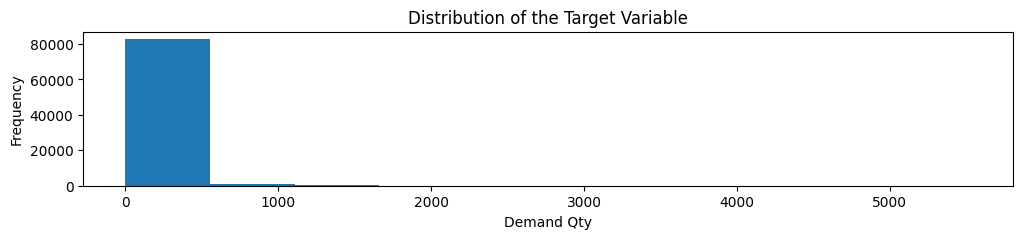

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize = (12, 2))
plt.hist(demand_df['Demand_Qty'], bins = 10)
plt.title("Distribution of the Target Variable")
plt.xlabel("Demand Qty")
plt.ylabel("Frequency")
plt.show()


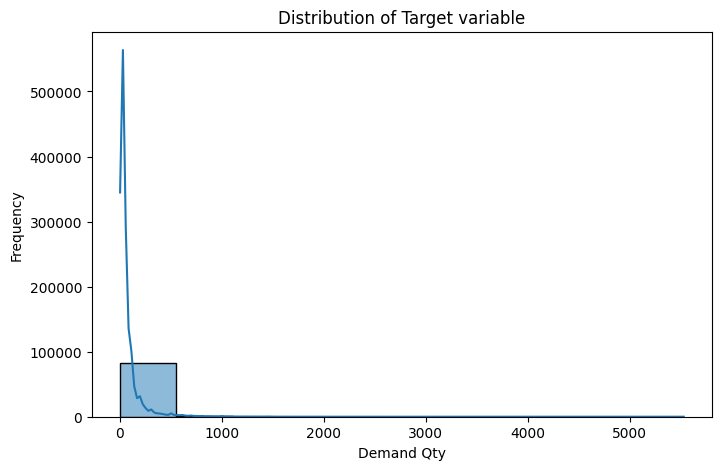

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(demand_df["Demand_Qty"], bins=10, kde=True)

plt.title("Distribution of Target variable")
plt.xlabel("Demand Qty")
plt.ylabel("Frequency")

plt.show()

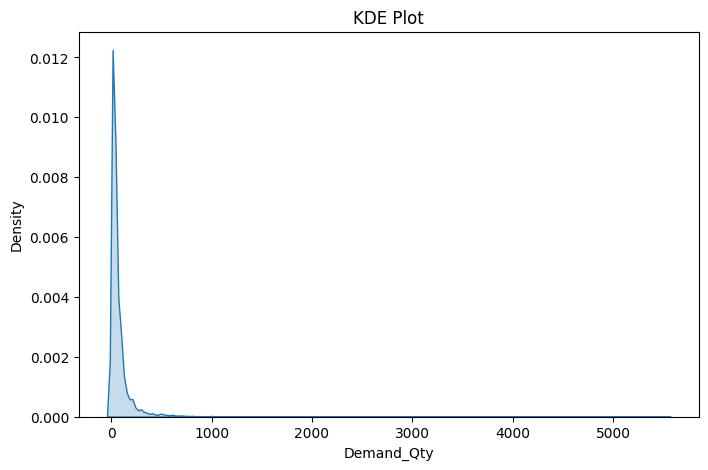

In [19]:
plt.figure(figsize=(8,5))

sns.kdeplot(data = demand_df, x="Demand_Qty", fill=True)

plt.title("KDE Plot")
plt.show()

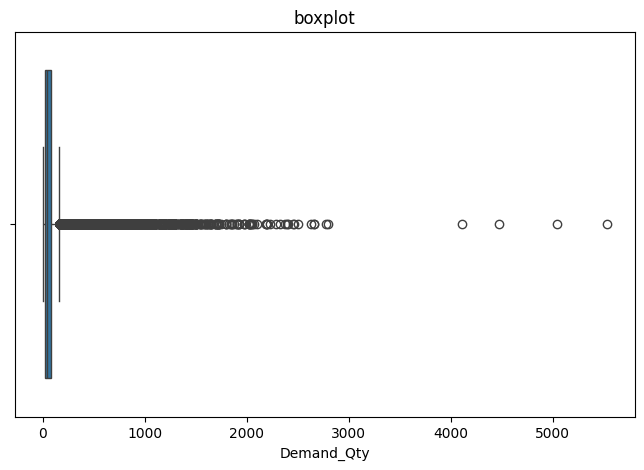

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(data=demand_df, x="Demand_Qty", fill=True)

plt.title("boxplot")
plt.show()

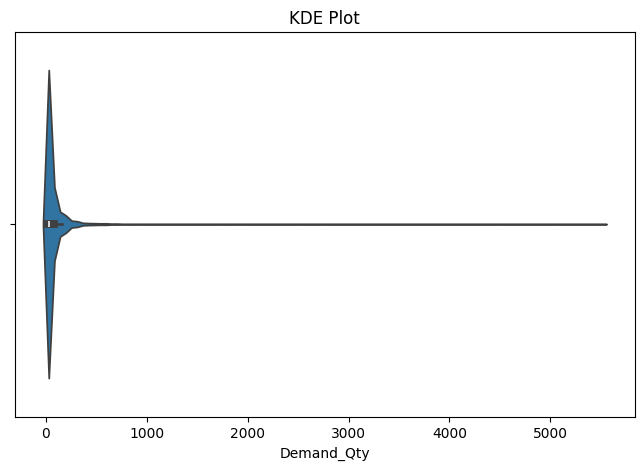

In [23]:
plt.figure(figsize=(8,5))

sns.violinplot(data=demand_df, x="Demand_Qty", fill=True)

plt.title("KDE Plot")
plt.show()

<Figure size 800x500 with 0 Axes>

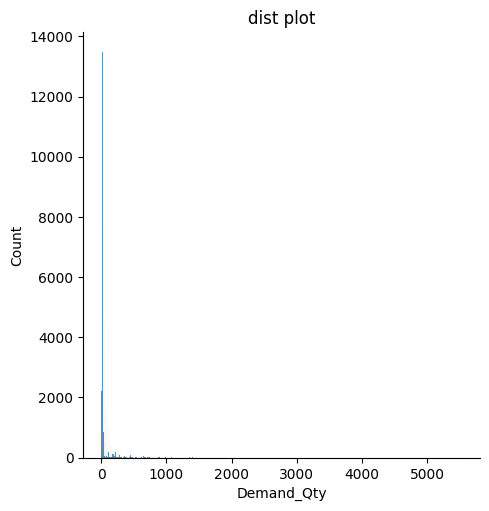

In [25]:
plt.figure(figsize=(8,5))

sns.displot(data=demand_df, x="Demand_Qty", fill=True)

plt.title("dist plot")
plt.show()

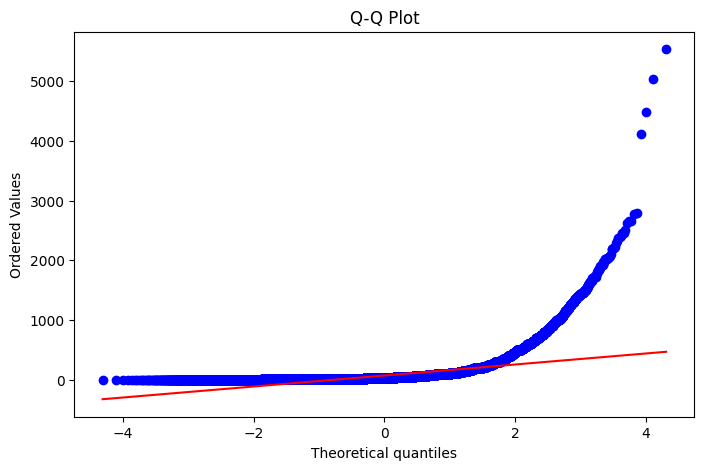

In [27]:
import scipy.stats as stats

plt.figure(figsize=(8,5))

stats.probplot(demand_df["Demand_Qty"], dist="norm", plot=plt)

plt.title("Q-Q Plot")
plt.show()

In [29]:
Q1 = demand_df["Demand_Qty"].quantile(0.25)
Q3 = demand_df["Demand_Qty"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = demand_df[
    (demand_df["Demand_Qty"] < lower_bound) |
    (demand_df["Demand_Qty"] > upper_bound)
]

print(outliers.shape)

Lower Bound: -65.5
Upper Bound: 162.5
(8049, 20)


## Product Analysis #

In [32]:
top_medicines = (
    demand_df
    .groupby(["MDCODE", "MDNAME"])["Demand_Qty"]
    .sum()
    .reset_index()
)

top_medicines

,MDCODE,MDNAME,Demand_Qty
0,1,OTACARE EAR DROPS,407764
1,2,SUPERCAM INJ,430606
2,3,F-MOL SUS,52154
3,4,FINORIL SYP 100ML,95946
4,5,KEELAC INJ,1144720
...,...,...,...
153,163,FEEMONEX-120 TABLET,2439
154,164,KEEN SOAP,960
155,165,MECLOFIN-B Cream,2472
156,166,GLYDIN MOUTH WASH,2155


In [34]:
top_medicines = top_medicines.sort_values(
    by="Demand_Qty",
    ascending=False
)

top_medicines

,MDCODE,MDNAME,Demand_Qty
4,5,KEELAC INJ,1144720
5,6,SUPERNAC AQ INJ,462984
1,2,SUPERCAM INJ,430606
0,1,OTACARE EAR DROPS,407764
18,19,MECOBA INJ,271711
...,...,...,...
125,135,FINETEL-H TAB,120
62,64,DOMPON-10 TAB,80
118,128,TORVECT-12 TAB,60
98,104,DISNOL 500ML,36


In [36]:
top20 = top_medicines.head(20)

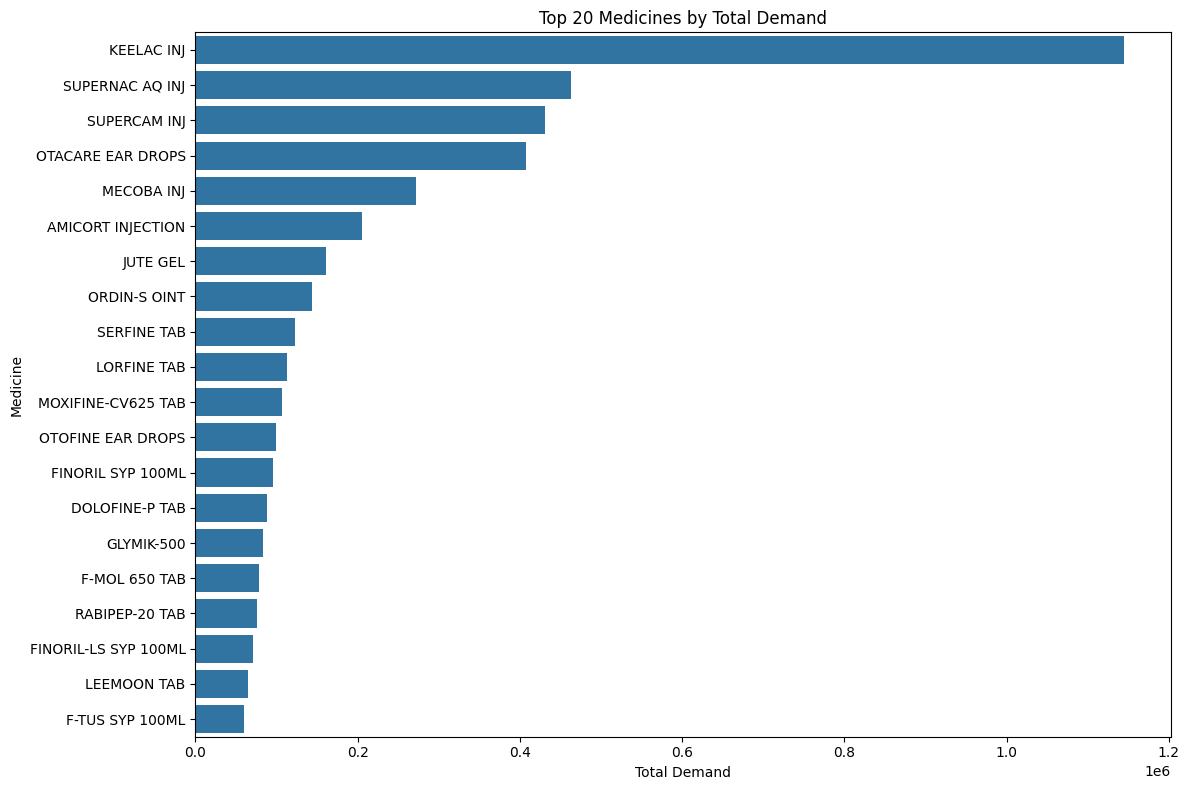

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))

sns.barplot(
    data=top20,
    x="Demand_Qty",
    y="MDNAME"
)

plt.title("Top 20 Medicines by Total Demand")
plt.xlabel("Total Demand")
plt.ylabel("Medicine")

plt.tight_layout()
plt.show()

In [40]:
total_demand = top_medicines["Demand_Qty"].sum()
total_demand

np.int64(6306227)

In [42]:
top20_demand = top20["Demand_Qty"].sum()
top20_demand

np.int64(4286484)

In [44]:
print((top20_demand / total_demand) * 100)

67.97224394237632


## Time Analysis ##

In [47]:
daily_demand = (
    demand_df
    .groupby("INVDT")["Demand_Qty"]
    .sum()
    .reset_index()
)

daily_demand["INVDT"] = pd.to_datetime(daily_demand["INVDT"])
daily_demand = daily_demand.sort_values("INVDT")

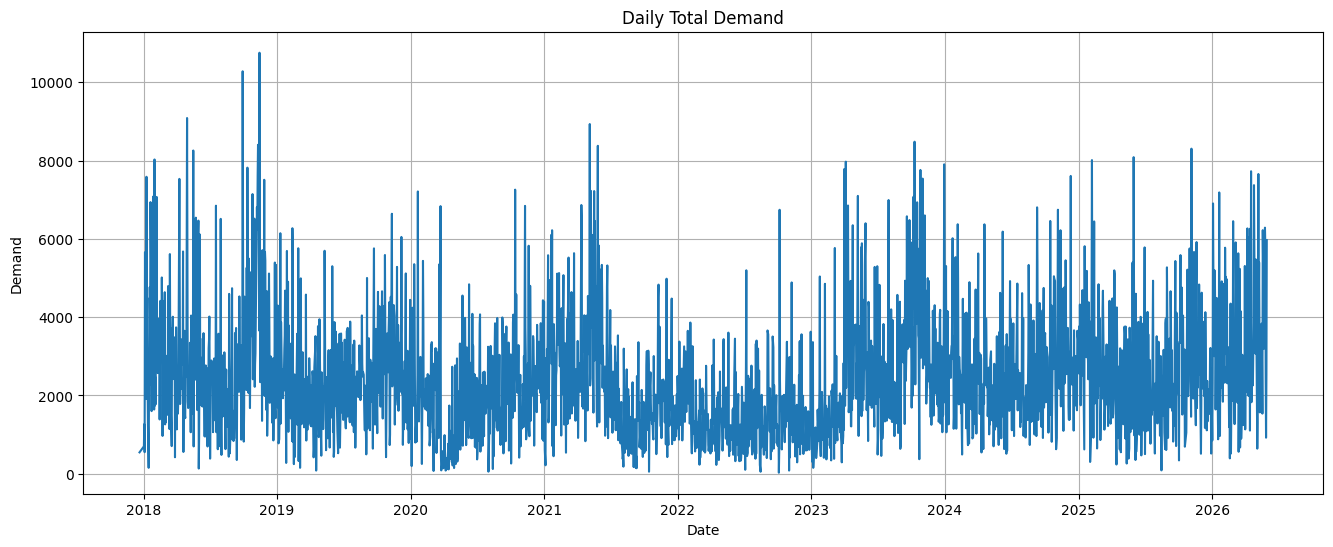

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,6))

plt.plot(
    daily_demand["INVDT"],
    daily_demand["Demand_Qty"]
)

plt.title("Daily Total Demand")
plt.xlabel("Date")
plt.ylabel("Demand")

plt.grid(True)

plt.show()

In [51]:
monthly_demand = (
    demand_df
    .groupby(["year", "month", "month_name"], as_index=False)["Demand_Qty"]
    .sum()
)

monthly_demand = monthly_demand.sort_values(["year", "month"])

monthly_demand.head()

,year,month,month_name,Demand_Qty
0,2018.0,1.0,January,83484
1,2018.0,2.0,February,80481
2,2018.0,3.0,March,72105
3,2018.0,4.0,April,76534
4,2018.0,5.0,May,85782


In [53]:
monthly_demand["Year_Month"] = (
    monthly_demand["month_name"].str[:3] +
    "-" +
    monthly_demand["year"].astype(int).astype(str)
)

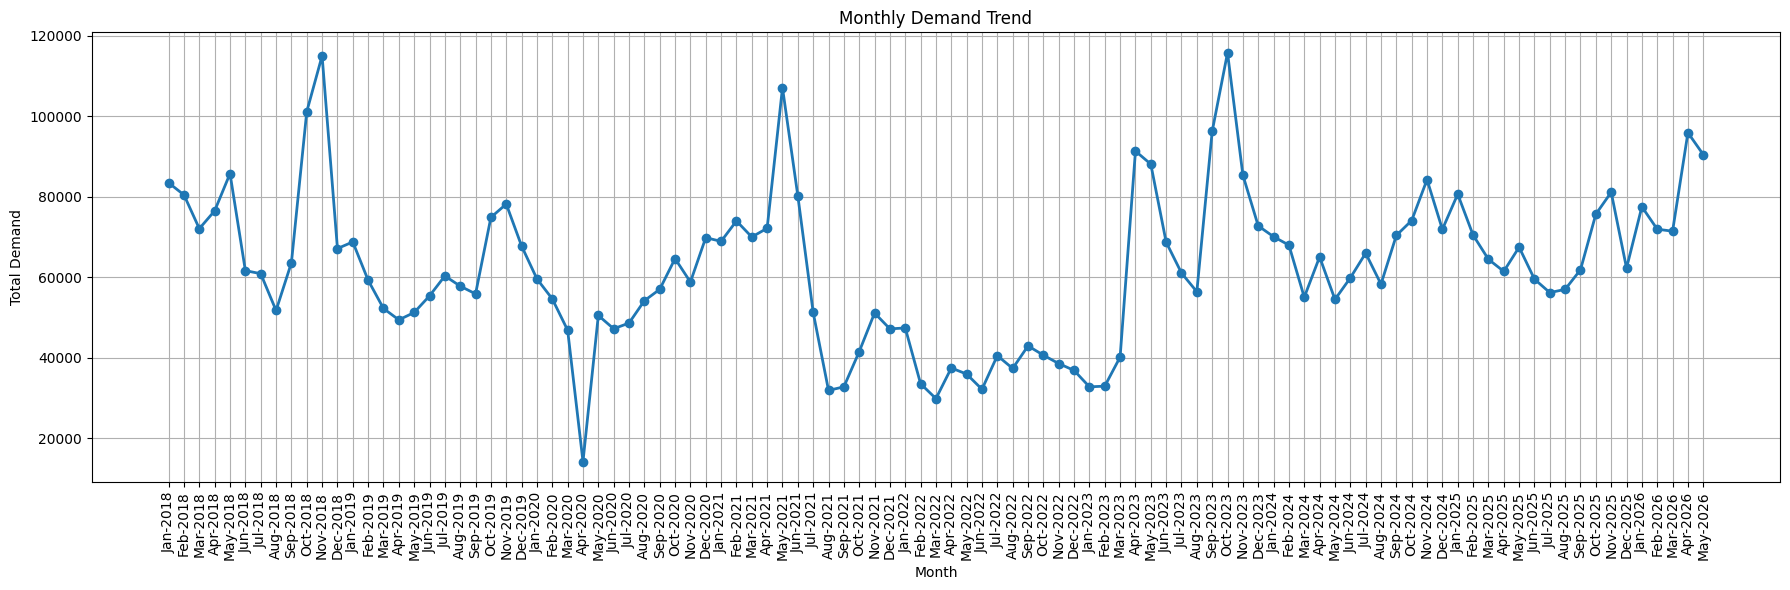

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18,6))

plt.plot(
    monthly_demand["Year_Month"],
    monthly_demand["Demand_Qty"],
    marker="o",
    linewidth=2
)

plt.xticks(rotation=90)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Demand")

plt.grid(True)

plt.tight_layout()
plt.show()

In [57]:
quarterly_demand = (
    demand_df
    .groupby(["year", "quarter"], as_index=False)["Demand_Qty"]
    .sum()
)

quarterly_demand["Year_Quarter"] = (
    "Q" +
    quarterly_demand["quarter"].astype(int).astype(str)
    + "-" +
    quarterly_demand["year"].astype(int).astype(str)
)

quarterly_demand

,year,quarter,Demand_Qty,Year_Quarter
0,2018.0,1.0,236070,Q1-2018
1,2018.0,2.0,223997,Q2-2018
2,2018.0,3.0,176317,Q3-2018
3,2018.0,4.0,283353,Q4-2018
4,2019.0,1.0,180379,Q1-2019
5,2019.0,2.0,156134,Q2-2019
6,2019.0,3.0,174091,Q3-2019
7,2019.0,4.0,220908,Q4-2019
8,2020.0,1.0,161163,Q1-2020
9,2020.0,2.0,112042,Q2-2020


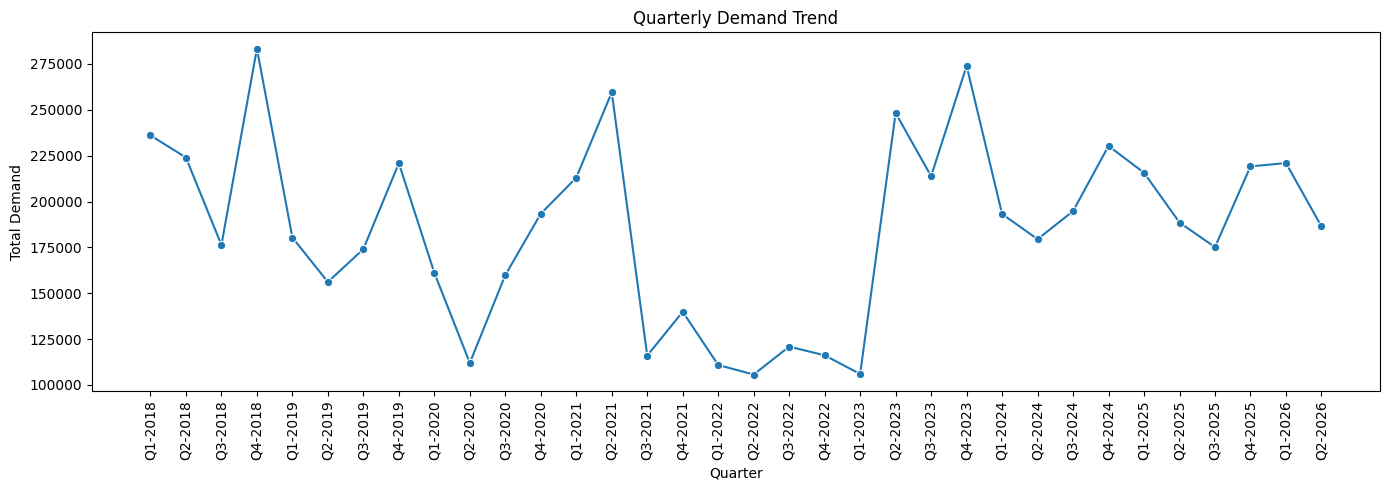

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,5))

sns.lineplot(
    data=quarterly_demand,
    x="Year_Quarter",
    y="Demand_Qty",
    marker="o"
)

plt.xticks(rotation=90)
plt.title("Quarterly Demand Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Demand")
plt.tight_layout()
plt.show()

In [61]:
weekend_demand = (
    demand_df
    .groupby("is_weekend", as_index=False)["Demand_Qty"]
    .sum()
)

weekend_demand

,is_weekend,Demand_Qty
0,False,5305478
1,True,1000204


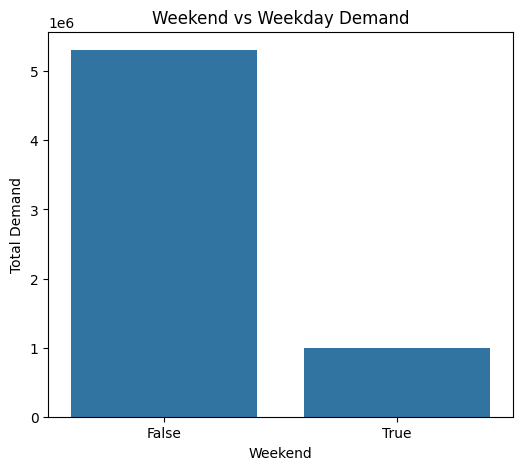

In [63]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=weekend_demand,
    x="is_weekend",
    y="Demand_Qty"
)

plt.title("Weekend vs Weekday Demand")
plt.xlabel("Weekend")
plt.ylabel("Total Demand")

plt.show()

In [65]:
daywise = (
    demand_df
    .groupby(
        ["day_of_week", "day_name"],
        as_index=False
    )["Demand_Qty"]
    .sum()
)

daywise = daywise.sort_values("day_of_week")

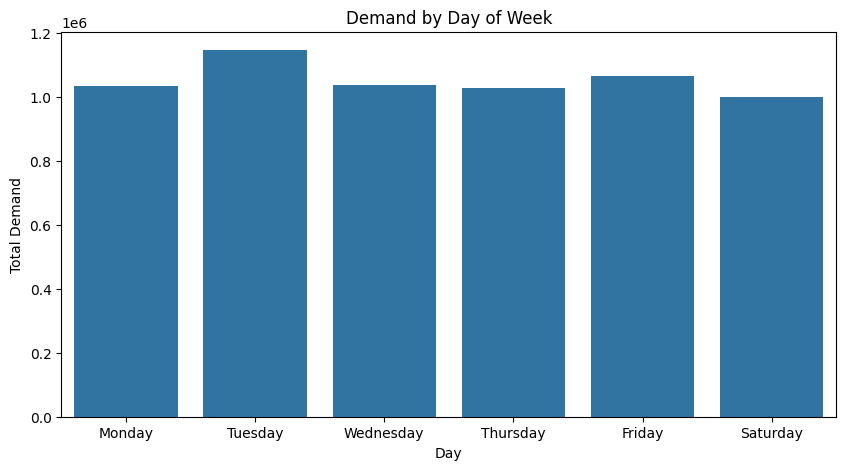

In [67]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=daywise,
    x="day_name",
    y="Demand_Qty"
)

plt.title("Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Demand")

plt.show()

In [69]:
seasonality = (
    demand_df
    .groupby(
        ["month", "month_name"],
        as_index=False
    )["Demand_Qty"]
    .sum()
)

seasonality = seasonality.sort_values("month")

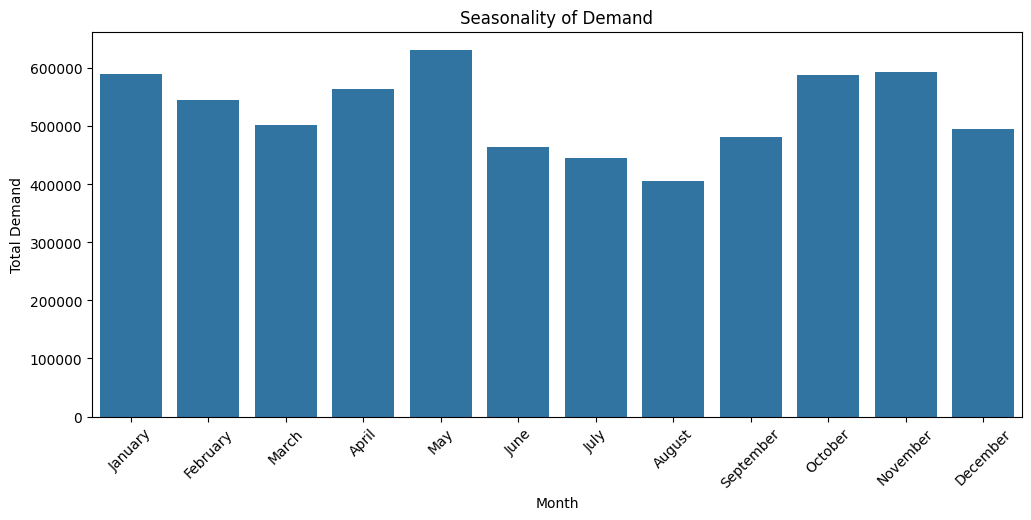

In [71]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=seasonality,
    x="month_name",
    y="Demand_Qty"
)

plt.title("Seasonality of Demand")
plt.xlabel("Month")
plt.ylabel("Total Demand")

plt.xticks(rotation=45)

plt.show()

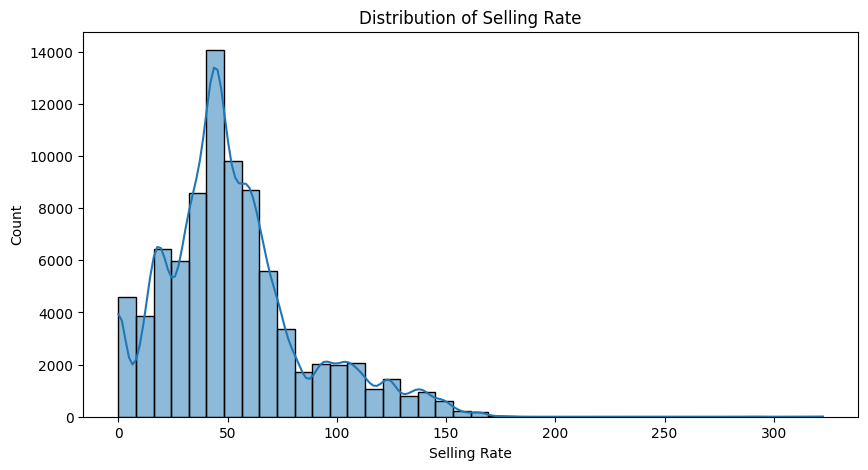

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    demand_df["Selling_Rate"],
    bins=40,
    kde=True
)

plt.title("Distribution of Selling Rate")
plt.xlabel("Selling Rate")
plt.ylabel("Count")

plt.show()

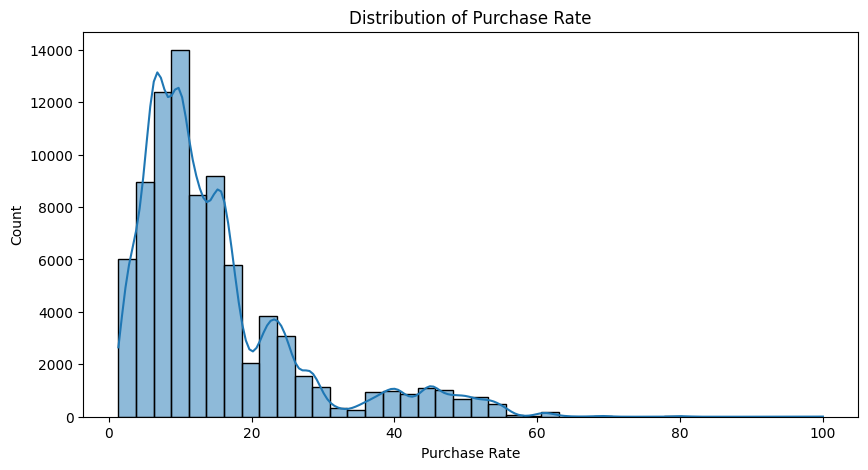

In [75]:
plt.figure(figsize=(10,5))

sns.histplot(
    demand_df["Purchase_Rate"],
    bins=40,
    kde=True
)

plt.title("Distribution of Purchase Rate")
plt.xlabel("Purchase Rate")
plt.ylabel("Count")

plt.show()

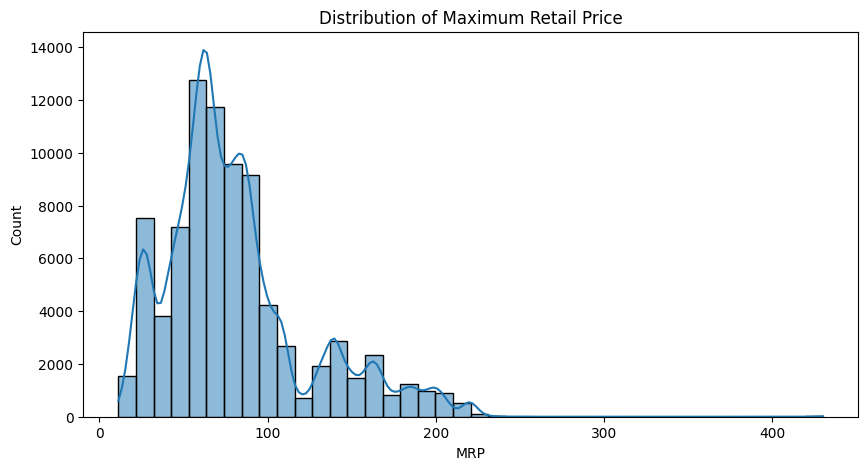

In [77]:
plt.figure(figsize=(10,5))

sns.histplot(
    demand_df["Maximum_Retail_Price"],
    bins=40,
    kde=True
)

plt.title("Distribution of Maximum Retail Price")
plt.xlabel("MRP")
plt.ylabel("Count")

plt.show()

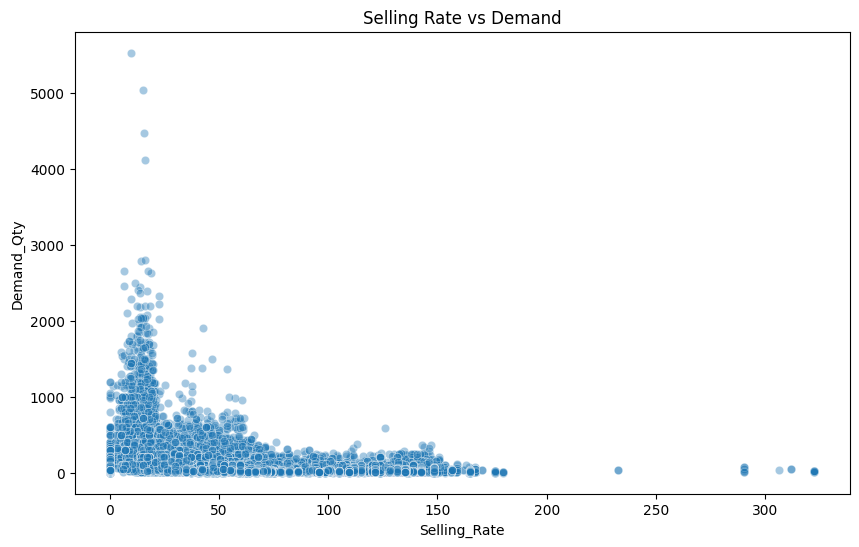

In [79]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=demand_df,
    x="Selling_Rate",
    y="Demand_Qty",
    alpha=0.4
)

plt.title("Selling Rate vs Demand")

plt.show()

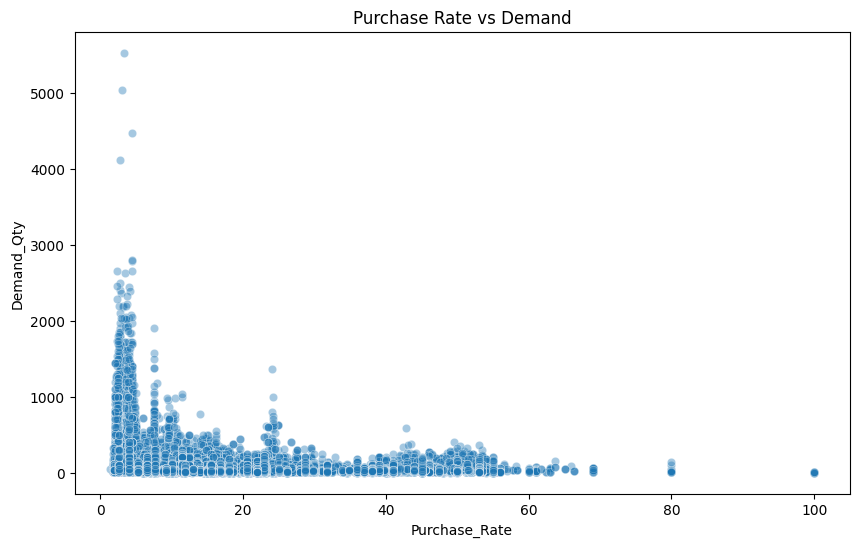

In [81]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=demand_df,
    x="Purchase_Rate",
    y="Demand_Qty",
    alpha=0.4
)

plt.title("Purchase Rate vs Demand")

plt.show()

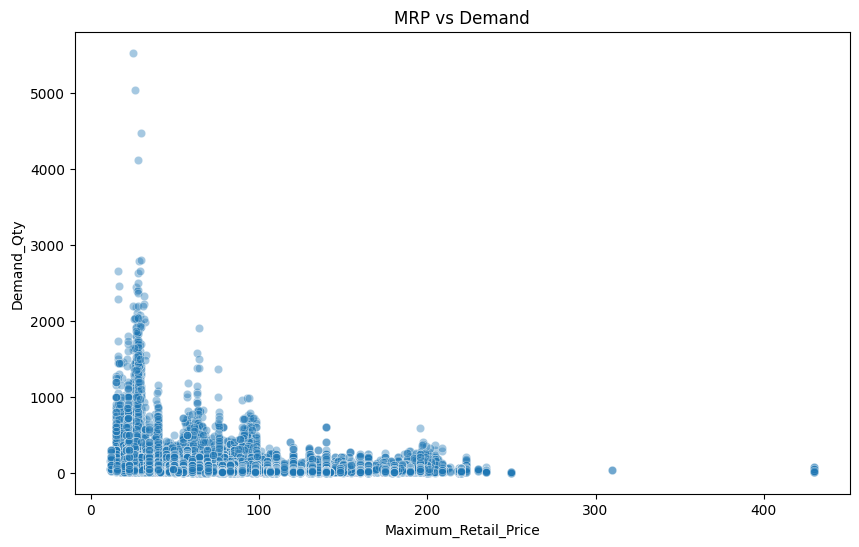

In [83]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=demand_df,
    x="Maximum_Retail_Price",
    y="Demand_Qty",
    alpha=0.4
)

plt.title("MRP vs Demand")

plt.show()

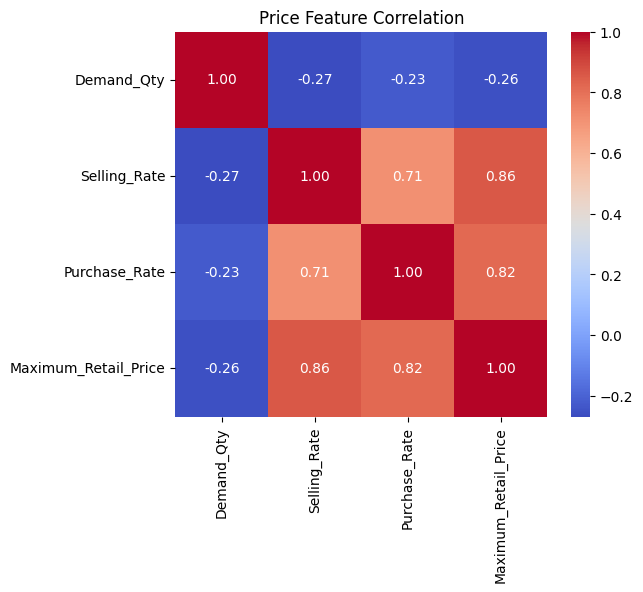

In [85]:
price_columns = [
    "Demand_Qty",
    "Selling_Rate",
    "Purchase_Rate",
    "Maximum_Retail_Price"
]

corr = demand_df[price_columns].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Price Feature Correlation")

plt.show()